# 📌 Extracción

In [1]:
import pandas as pd
import numpy as np
import requests
import json
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")


In [2]:
url = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json"

response = requests.get(url)

data_json = response.json()

print("Datos extraídos correctamente")
print(f"Cantidad de registros: {len(data_json)}")

Datos extraídos correctamente
Cantidad de registros: 7267


In [3]:
df = pd.json_normalize(data_json)

df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [6]:
df.columns
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [7]:
df.isnull().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly
count,7267.000000,7267.000000,7267.000000
mean,0.162653,32.346498,64.720098
std,0.369074,24.571773,30.129572
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.425000
50%,0.000000,29.000000,70.300000
75%,0.000000,55.000000,89.875000
max,1.000000,72.000000,118.750000


In [10]:
df = df.drop_duplicates()

print("Duplicados eliminados")

Duplicados eliminados


In [11]:
df['account.Charges.Total'] = pd.to_numeric(
    df['account.Charges.Total'], errors='coerce'
)

df['account.Charges.Monthly'] = pd.to_numeric(
    df['account.Charges.Monthly'], errors='coerce'
)

In [12]:
df = df.fillna(df.median(numeric_only=True))

In [13]:
df["Cuentas_Diarias"] = df["account.Charges.Monthly"] / 30

df[["account.Charges.Monthly", "Cuentas_Diarias"]].head()

,account.Charges.Monthly,Cuentas_Diarias
0,65.6,2.186667
1,59.9,1.996667
2,73.9,2.463333
3,98.0,3.266667
4,83.9,2.796667


# 🔧 Transformación

In [14]:
df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

In [15]:
df = df.rename(columns={

    "customerID": "Cliente_ID",
    "Churn": "Evasion",
    "account.Charges.Monthly": "Cargo_Mensual",
    "account.Charges.Total": "Cargo_Total",
    "account.tenure": "Meses_Contrato"

})

df.head()

,Cliente_ID,Evasion,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,Cargo_Mensual,Cargo_Total,Cuentas_Diarias
0,0002-ORFBO,0.0,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0.0,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1.0,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1.0,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1.0,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


In [16]:
df.describe()

,Evasion,customer.SeniorCitizen,customer.tenure,Cargo_Mensual,Cargo_Total,Cuentas_Diarias
count,7043.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000
mean,0.265370,0.162653,32.346498,64.720098,2279.287581,2.157337
std,0.441561,0.369074,24.571773,30.129572,2267.178963,1.004319
min,0.000000,0.000000,0.000000,18.250000,18.800000,0.608333
25%,0.000000,0.000000,9.000000,35.425000,401.400000,1.180833
50%,0.000000,0.000000,29.000000,70.300000,1391.000000,2.343333
75%,1.000000,0.000000,55.000000,89.875000,3778.525000,2.995833
max,1.000000,1.000000,72.000000,118.750000,8684.800000,3.958333


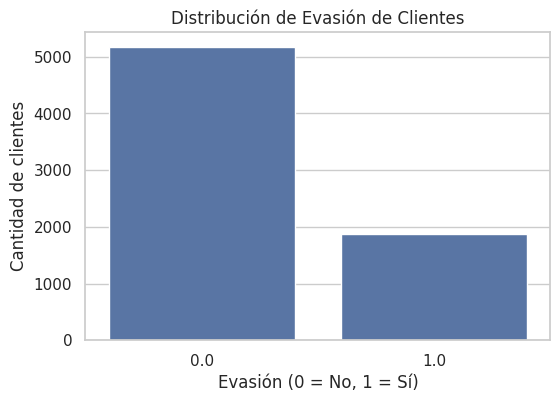

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(x="Evasion", data=df)

plt.title("Distribución de Evasión de Clientes")
plt.xlabel("Evasión (0 = No, 1 = Sí)")
plt.ylabel("Cantidad de clientes")

plt.show()

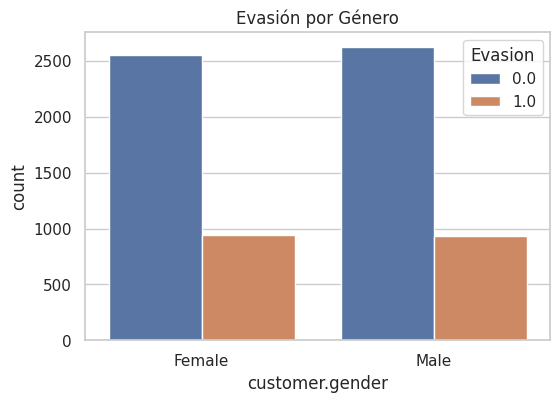

In [18]:
plt.figure(figsize=(6,4))

sns.countplot(x="customer.gender", hue="Evasion", data=df)

plt.title("Evasión por Género")

plt.show()

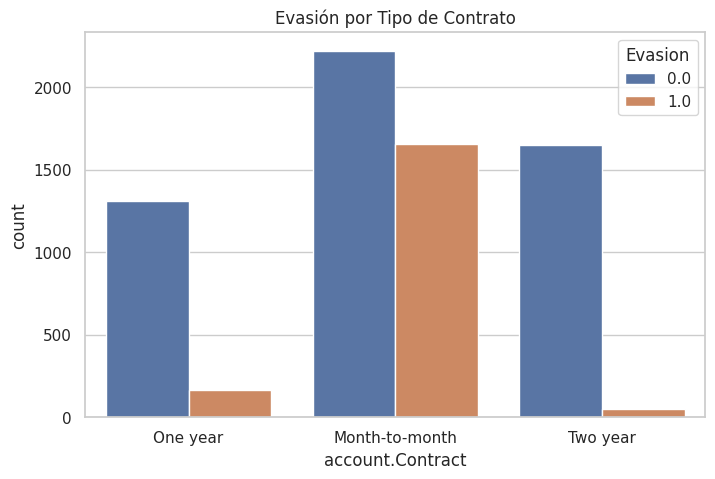

In [19]:
plt.figure(figsize=(8,5))

sns.countplot(x="account.Contract", hue="Evasion", data=df)

plt.title("Evasión por Tipo de Contrato")

plt.show()

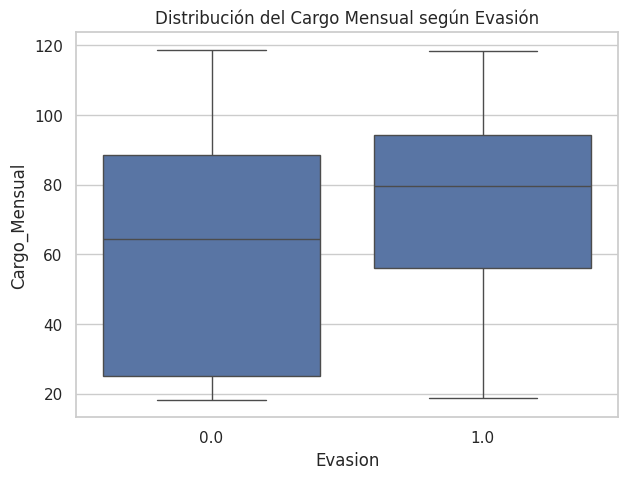

In [20]:
plt.figure(figsize=(7,5))

sns.boxplot(x="Evasion", y="Cargo_Mensual", data=df)

plt.title("Distribución del Cargo Mensual según Evasión")

plt.show()

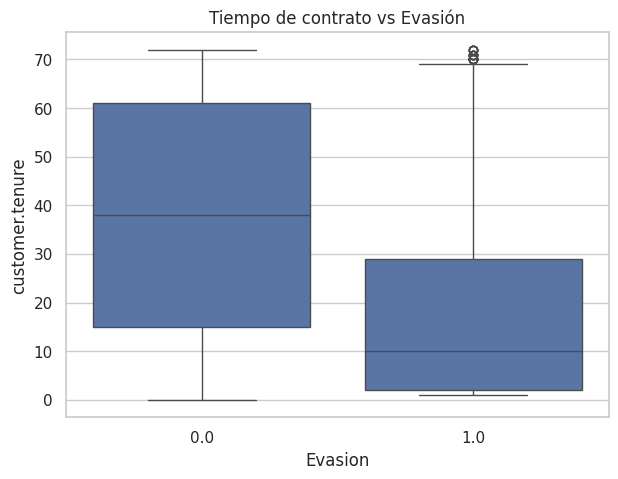

In [23]:
plt.figure(figsize=(7,5))

sns.boxplot(x="Evasion", y="customer.tenure", data=df)

plt.title("Tiempo de contrato vs Evasión")

plt.show()

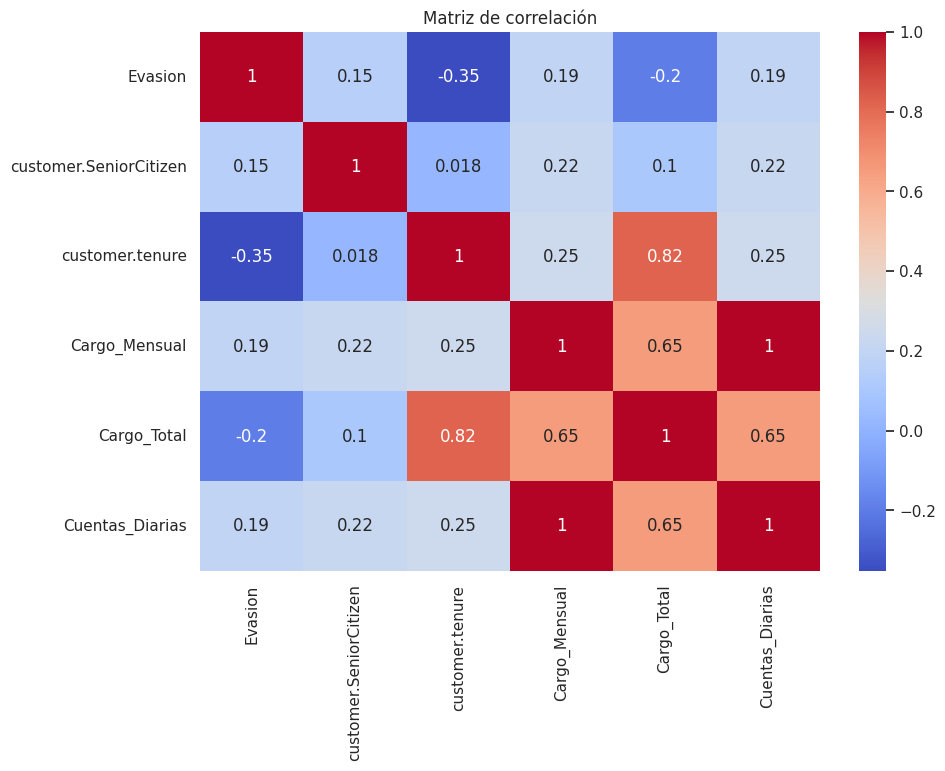

In [24]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,7))

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Matriz de correlación")

plt.show()

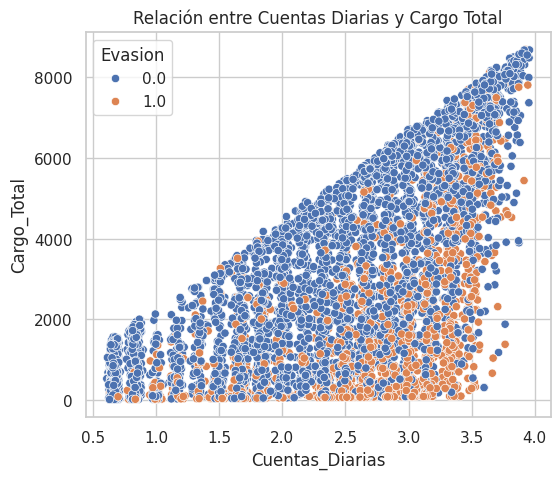

In [25]:
plt.figure(figsize=(6,5))

sns.scatterplot(
    x="Cuentas_Diarias",
    y="Cargo_Total",
    hue="Evasion",
    data=df
)

plt.title("Relación entre Cuentas Diarias y Cargo Total")

plt.show()